
# ==========================================================
# Multi-Class Fabric Defect Detection Using Machine Learning and Feature Engineering Techniques
# ==========================================================


# ==========================================================
# DATASET INFORMATION
# ==========================================================

"""
Dataset Name:
Multi-Class Fabric Defect Detection Dataset

Dataset Link:
https://www.kaggle.com/datasets/ziya07/multi-class-fabric-defect-detection-dataset

Note:
Download the dataset and upload it to Google Drive.

Update the dataset path below if required.
"""

## Project Deliverables
---

The complete project resources are available in the following Google Drive folder:

https://drive.google.com/drive/folders/1b23FZbaBkfEq4z22idWgK_LYCLwPIAt1?usp=sharing

This folder contains:

* Front-End Application
* Project Presentation Slides
* IEEE Style Project Report (Additional Documentation / Bonus Work)


# ==========================================================
# DATASET PATH
# ==========================================================
# Change this path according to your Google Drive location
dataset_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Dataset"

processed_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Processed_Dataset"

Submitted by:
---
1.   Muhammad Mamoon Irfan   F2023266192
2.   MUHAMMAD ZAIN-UL-ABADEEN  F2023266007
---

# ==========================================================

# PROJECT PROGRESS SUMMARY

# ==========================================================

"""

COMPLETED:
✓ Dataset Analysis
✓ Data Preprocessing
✓ Label Encoding
✓ Train/Test Split
✓ HOG Feature Extraction
✓ Color Histogram Feature Extraction
✓ Spatial Binning Feature Extraction
✓ Feature Fusion (Combined Features)
✓ Naive Bayes
✓ Support Vector Machine (SVM)
✓ Logistic Regression
✓ Multi-Layer Perceptron (MLP)
✓ Convolutional Neural Network (CNN)
✓ Model Evaluation
✓ Confusion Matrix Analysis
✓ GUI Development (Tkinter)
✓ PDF Report Generation
✓ IEEE Style Project Report
✓ Project Presentation Slides

BEST RESULT:
MLP + Combined Features

FINAL ACCURACY:
90.55%

---

## OVERALL PROJECT COMPLETION

Machine Learning Phase : 100%
Deep Learning Phase    : 100%
GUI Development        : 100%
Documentation          : 100%
Presentation           : 100%

Current Submission Progress:
100%

FINAL DEPLOYED SYSTEM:
Fabric Defect Detection System
(Tkinter GUI + PDF Reporting Module)

FUTURE WORK:
YOLO-Based Defect Localization
EfficientDet-Based Detection
Real-Time Camera Integration
Mobile Application Deployment

"""


# ==========================================================
# PROJECT CODE STARTS BELOW
# ==========================================================

PHASE 1 — Dataset Inspection
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
dataset_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project"

In [ ]:
print(os.path.exists("/content/drive/MyDrive/ML_Fabric_Defect_Project/Dataset"))

True


In [ ]:
classes = sorted(os.listdir("/content/drive/MyDrive/ML_Fabric_Defect_Project/Dataset"))

print("Classes:")
print(classes)

Classes:
['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']


In [ ]:
image_counts = {}

for cls in classes:
    class_path = os.path.join("/content/drive/MyDrive/ML_Fabric_Defect_Project/Dataset", cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        image_counts[cls] = count

image_counts

{'Broken stitch': 112,
 'Needle mark': 108,
 'Pinched fabric': 108,
 'Vertical': 101,
 'defect free': 1666,
 'hole': 281,
 'horizontal': 136,
 'lines': 157,
 'stain': 398}

In [ ]:
total_images = sum(image_counts.values())

print("Total Classes :", len(image_counts))
print("Total Images  :", total_images)

for cls,count in image_counts.items():
    print(f"{cls}: {count}")

Total Classes : 9
Total Images  : 3067
Broken stitch: 112
Needle mark: 108
Pinched fabric: 108
Vertical: 101
defect free: 1666
hole: 281
horizontal: 136
lines: 157
stain: 398


PHASE 2
Exploratory Data Analysis (EDA)
---
Find:
Class distribution
Sample images

* Class distribution
* Sample images
* Image sizes
* Corrupted images
* Color channels
* Dataset quality

---

Class Distribution Graph
---

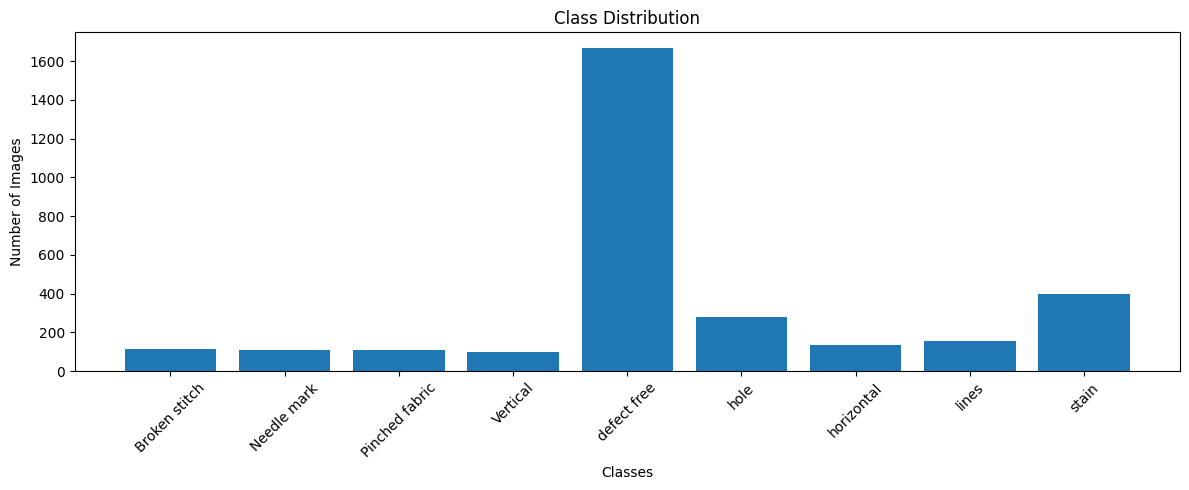

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(image_counts.keys(), image_counts.values())

plt.xticks(rotation=45)

plt.title("Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.tight_layout()

plt.show()

Save Graph
---

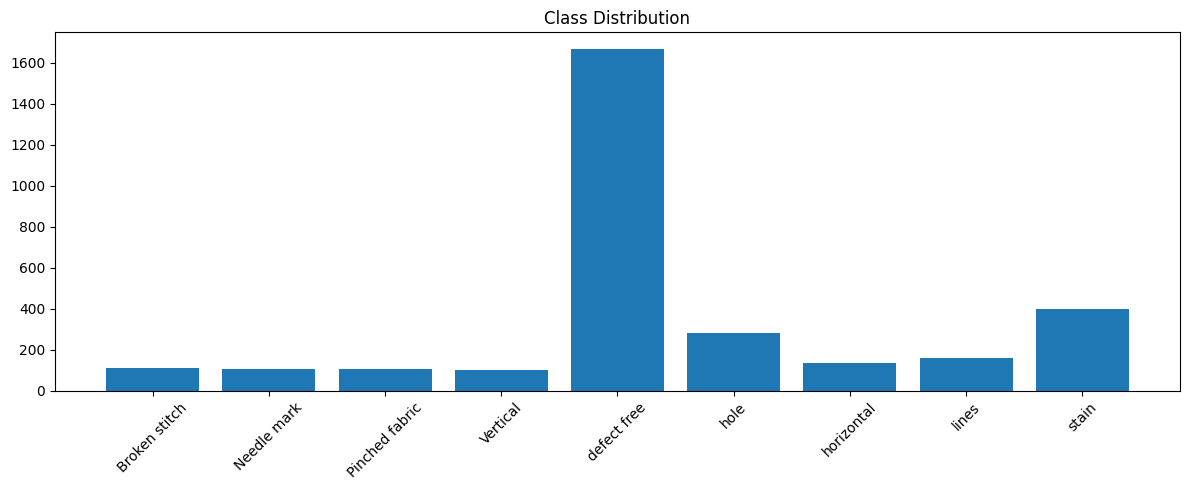

In [ ]:
plt.figure(figsize=(12,5))

plt.bar(image_counts.keys(), image_counts.values())

plt.xticks(rotation=45)

plt.title("Class Distribution")

plt.tight_layout()

plt.savefig("class_distribution.png")

plt.show()

Sample Images Display
---

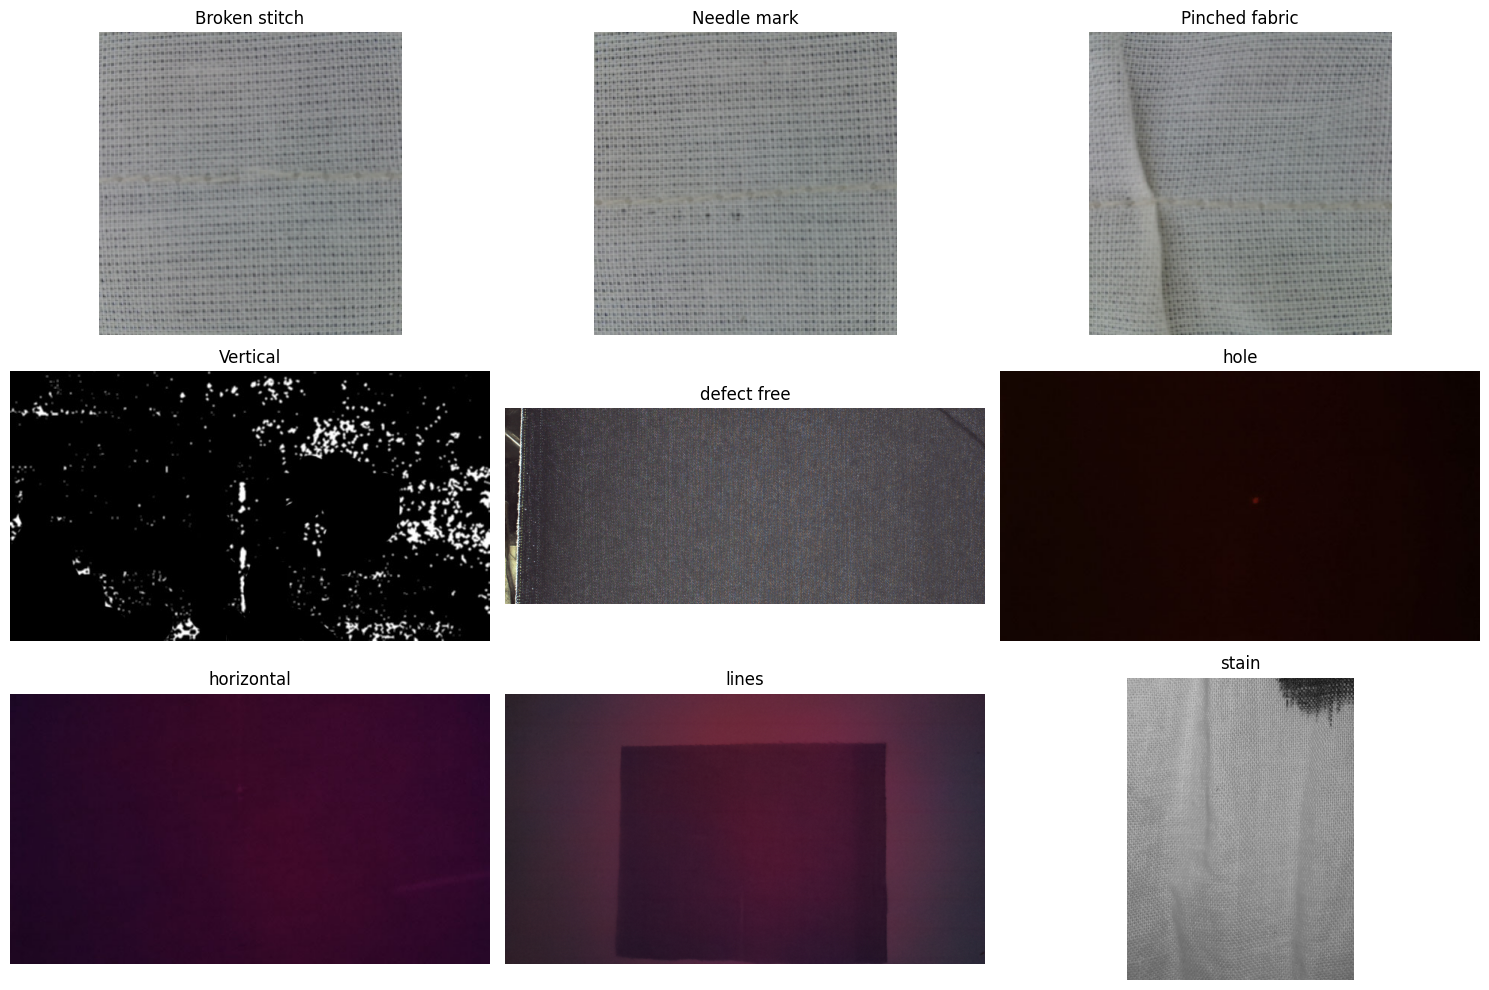

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Dataset"

classes = sorted(os.listdir(dataset_path))

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
plt.show()

Image Size Analysis
---

In [ ]:
sizes = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is not None:

            h,w = img.shape[:2]

            sizes.append((h,w))

In [ ]:
sizes[:10]

[(224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224)]

In [ ]:
unique_sizes = set(sizes)

print("Unique Image Sizes:", len(unique_sizes))

list(unique_sizes)[:20]

Unique Image Sizes: 14


[(4608, 3456),
 (264, 221),
 (1488, 1984),
 (720, 1280),
 (3456, 4608),
 (256, 4096),
 (1000, 2446),
 (360, 640),
 (224, 224),
 (288, 233),
 (274, 201),
 (264, 219),
 (1984, 1488),
 (270, 220)]

In [ ]:
corrupted = 0

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            corrupted += 1

print("Corrupted Images:", corrupted)

Corrupted Images: 0


PHASE 2 — Image Properties Analysis
---

In [ ]:
import os
import cv2

channel_info = {}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is not None:

            channel_info[img.shape[-1]] = channel_info.get(img.shape[-1],0)+1

print(channel_info)

{3: 3067}


File Formats Check
---

In [ ]:
extensions = {}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        ext = img_name.split(".")[-1].lower()

        extensions[ext] = extensions.get(ext,0)+1

print(extensions)

{'jpg': 2917, 'png': 150}


Preprocessing Phase
---

PHASE 3.1 — Resize & Save All Images
---

In [ ]:
import os
import cv2
from tqdm import tqdm

dataset_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Dataset"
processed_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Processed_Dataset"

TARGET_SIZE = (224, 224)

total_processed = 0

for cls in tqdm(classes):

    source_class_path = os.path.join(dataset_path, cls)
    target_class_path = os.path.join(processed_path, cls)

    for img_name in os.listdir(source_class_path):

        source_img_path = os.path.join(source_class_path, img_name)

        img = cv2.imread(source_img_path)

        if img is None:
            continue

        resized_img = cv2.resize(img, TARGET_SIZE)

        save_path = os.path.join(target_class_path, img_name)

        cv2.imwrite(save_path, resized_img)

        total_processed += 1

print("Total Processed Images:", total_processed)

100%|██████████| 9/9 [12:17<00:00, 82.00s/it]

Total Processed Images: 3067


In [ ]:
import os

processed_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Processed_Dataset"

os.makedirs(processed_path, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(processed_path, cls), exist_ok=True)

print("All class folders created successfully")
print(os.listdir(processed_path))

All class folders created successfully
['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']


Verification
---

In [ ]:
sample_class = classes[0]

sample_path = os.path.join(
    processed_path,
    sample_class,
    os.listdir(os.path.join(processed_path, sample_class))[0]
)

img = cv2.imread(sample_path)

print(img.shape)

(224, 224, 3)


PHASE 4 — Label Encoding
--

In [ ]:
# =====================================
# PHASE 4 : LABEL ENCODING
# =====================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

labels_text = []

for cls in classes:

    class_path = os.path.join(processed_path, cls)

    total_files = len(os.listdir(class_path))

    labels_text.extend([cls] * total_files)

label_encoder.fit(labels_text)

print("Total Classes:", len(label_encoder.classes_))
print("\nClass Mapping:\n")

for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")

Total Classes: 9

Class Mapping:

0 -> Broken stitch
1 -> Needle mark
2 -> Pinched fabric
3 -> Vertical
4 -> defect free
5 -> hole
6 -> horizontal
7 -> lines
8 -> stain


Load Dataset
---

In [ ]:
# =====================================
# PHASE 4 : LOAD ALL IMAGES
# =====================================

images = []
labels = []

for cls in classes:

    class_path = os.path.join(processed_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)

        labels.append(cls)

print("Images Loaded :", len(images))
print("Labels Loaded :", len(labels))

Images Loaded : 3067
Labels Loaded : 3067


Convert To ML Ready Format
---

In [ ]:
# =====================================
# PHASE 4 : ML READY DATASET
# =====================================

import numpy as np

images = np.array(images)

labels_encoded = label_encoder.transform(labels)

labels_encoded = np.array(labels_encoded)

print("Images Shape :", images.shape)
print("Labels Shape :", labels_encoded.shape)

print("\nSample Labels:")
print(labels_encoded[:20])

Images Shape : (3067, 224, 224, 3)
Labels Shape : (3067,)

Sample Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


PHASE 5 — Train/Test Split
---

In [ ]:
# =====================================
# PHASE 5 : TRAIN TEST SPLIT
# =====================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.20,
    random_state=42,
    stratify=labels_encoded
)

print("Train Images :", X_train.shape)
print("Test Images  :", X_test.shape)

print("Train Labels :", y_train.shape)
print("Test Labels  :", y_test.shape)

Train Images : (2453, 224, 224, 3)
Test Images  : (614, 224, 224, 3)
Train Labels : (2453,)
Test Labels  : (614,)


In [ ]:
# =====================================
# CLASS DISTRIBUTION CHECK
# =====================================

import numpy as np

print("Training Distribution:\n")

unique, counts = np.unique(y_train, return_counts=True)

for cls, count in zip(unique, counts):
    print(f"{cls} : {count}")

Training Distribution:

0 : 90
1 : 86
2 : 86
3 : 81
4 : 1332
5 : 225
6 : 109
7 : 126
8 : 318


In [ ]:
print("\nTesting Distribution:\n")

unique, counts = np.unique(y_test, return_counts=True)

for cls, count in zip(unique, counts):
    print(f"{cls} : {count}")


Testing Distribution:

0 : 22
1 : 22
2 : 22
3 : 20
4 : 334
5 : 56
6 : 27
7 : 31
8 : 80


PHASE 6 — HOG Feature Extraction
----

In [ ]:
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt

SAMPLE IMAGE SELECT
---

In [ ]:
sample_image = X_train[0]

print(sample_image.shape)

(224, 224, 3)


GRAYSCALE
---

In [ ]:
gray_image = cv2.cvtColor(sample_image, cv2.COLOR_RGB2GRAY)

print(gray_image.shape)

(224, 224)


HOG FEATURE EXTRACTION
----

In [ ]:
hog_features, hog_image = hog(
    gray_image,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    block_norm='L2-Hys'
)

print("HOG Feature Length :", len(hog_features))

HOG Feature Length : 26244


HOG VISUALIZATION
---

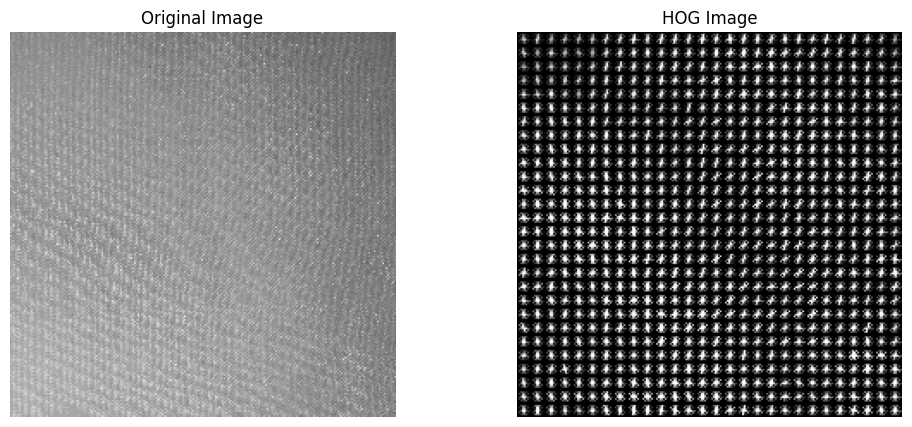

In [ ]:
hog_image = exposure.rescale_intensity(
    hog_image,
    in_range=(0,10)
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Image")
plt.axis("off")

plt.show()

PHASE 7 — HOG Feature Matrix Creation
---

In [ ]:
from skimage.feature import hog

def extract_hog_features(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=False
    )

    return features

EXTRACT HOG FEATURES - TRAIN
---

In [ ]:
X_train_hog = []

for img in X_train:

    features = extract_hog_features(img)

    X_train_hog.append(features)

X_train_hog = np.array(X_train_hog)

print("Train HOG Shape :", X_train_hog.shape)

Train HOG Shape : (2453, 26244)


EXTRACT HOG FEATURES - TEST
---

In [ ]:
X_test_hog = []

for img in X_test:

    features = extract_hog_features(img)

    X_test_hog.append(features)

X_test_hog = np.array(X_test_hog)

print("Test HOG Shape :", X_test_hog.shape)

Test HOG Shape : (614, 26244)


FEATURE VECTOR CHECK
---

In [ ]:
print("Single Feature Length :", len(X_train_hog[0]))

Single Feature Length : 26244


PHASE 8 — Feature Scaling
---

In [ ]:
from sklearn.preprocessing import StandardScaler

FIT SCALER ON TRAIN
---

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_hog)

print(X_train_scaled.shape)

(2453, 26244)


TRANSFORM TEST
---

In [ ]:
X_test_scaled = scaler.transform(X_test_hog)

print(X_test_scaled.shape)

(614, 26244)


PHASE 9 — FIRST MODEL (SVM)
---

TRAIN SVM
---

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

print("SVM Training Complete")

SVM Training Complete


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


PREDICTIONS
---

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predictions Generated")

Predictions Generated


ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy =", round(svm_accuracy * 100, 2), "%")

SVM Accuracy = 86.16 %


CLASSIFICATION REPORT
---

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)

                precision    recall  f1-score   support

 Broken stitch       0.79      0.86      0.83        22
   Needle mark       0.90      0.82      0.86        22
Pinched fabric       0.84      0.95      0.89        22
      Vertical       0.82      0.70      0.76        20
   defect free       0.95      0.91      0.93       334
          hole       0.73      0.84      0.78        56
    horizontal       0.86      0.67      0.75        27
         lines       0.80      0.90      0.85        31
         stain       0.68      0.76      0.72        80

      accuracy                           0.86       614
     macro avg       0.82      0.82      0.82       614
  weighted avg       0.87      0.86      0.86       614



CONFUSION MATRIX
---

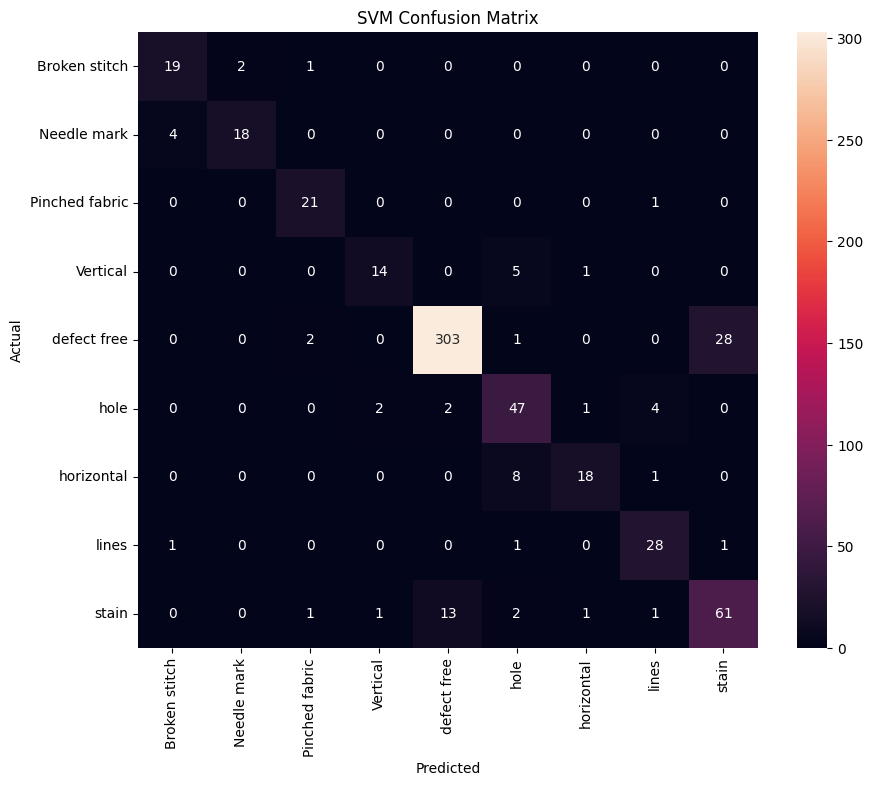

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

PHASE 10 : NAIVE BAYES MODEL
---

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

print("Naive Bayes Training Completed")

Naive Bayes Training Completed


NAIVE BAYES PREDICTIONS
---

In [ ]:
y_pred_nb = nb_model.predict(X_test_scaled)

print("Predictions Generated")

Predictions Generated


NAIVE BAYES ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")

Naive Bayes Accuracy: 58.14%


CLASSIFICATION REPORT
---

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=label_encoder.classes_
    )
)

                precision    recall  f1-score   support

 Broken stitch       0.69      0.50      0.58        22
   Needle mark       0.67      0.82      0.73        22
Pinched fabric       0.67      0.82      0.73        22
      Vertical       0.45      0.85      0.59        20
   defect free       0.91      0.54      0.68       334
          hole       0.23      0.09      0.13        56
    horizontal       0.53      0.67      0.59        27
         lines       0.62      0.97      0.76        31
         stain       0.29      0.72      0.41        80

      accuracy                           0.58       614
     macro avg       0.56      0.66      0.58       614
  weighted avg       0.70      0.58      0.59       614



CONFUSION MATRIX
---

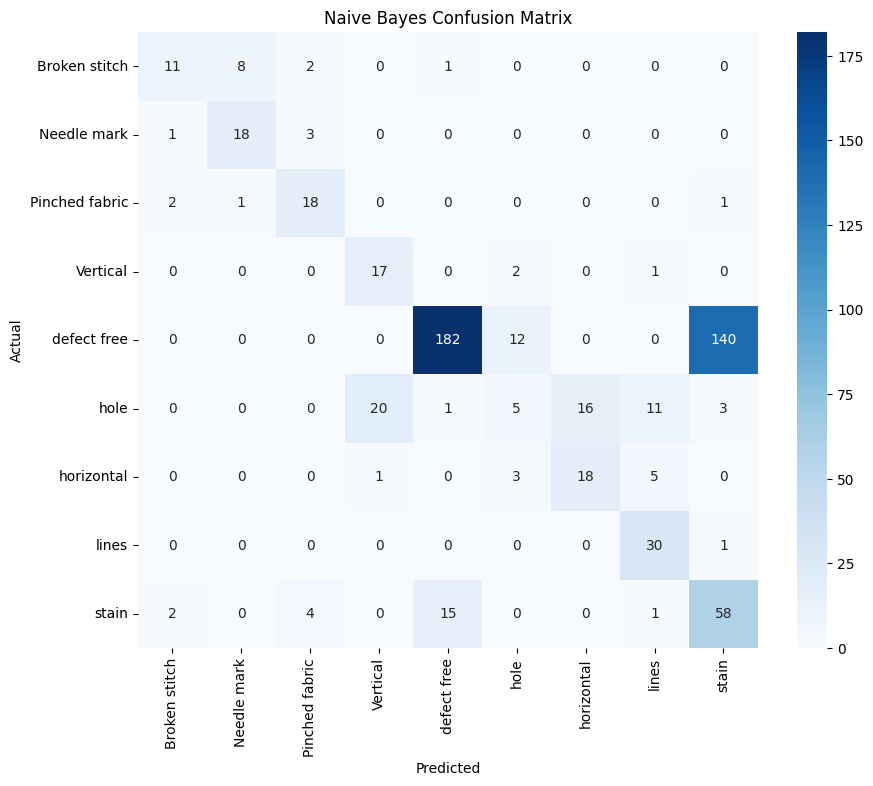

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

PHASE 11 : LOGISTIC REGRESSION
---

TRAIN LOGISTIC REGRESSION
---

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Training Completed")

Logistic Regression Training Completed


PREDICTIONS
---

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("Predictions Generated")

Predictions Generated


ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

Logistic Regression Accuracy: 85.67%


CLASSIFICATION REPORT
---

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

                precision    recall  f1-score   support

 Broken stitch       0.82      0.82      0.82        22
   Needle mark       0.90      0.86      0.88        22
Pinched fabric       0.95      0.91      0.93        22
      Vertical       0.93      0.70      0.80        20
   defect free       0.90      0.95      0.92       334
          hole       0.71      0.84      0.77        56
    horizontal       0.81      0.63      0.71        27
         lines       0.90      0.90      0.90        31
         stain       0.71      0.59      0.64        80

      accuracy                           0.86       614
     macro avg       0.85      0.80      0.82       614
  weighted avg       0.85      0.86      0.85       614



CONFUSION MATRIX
---

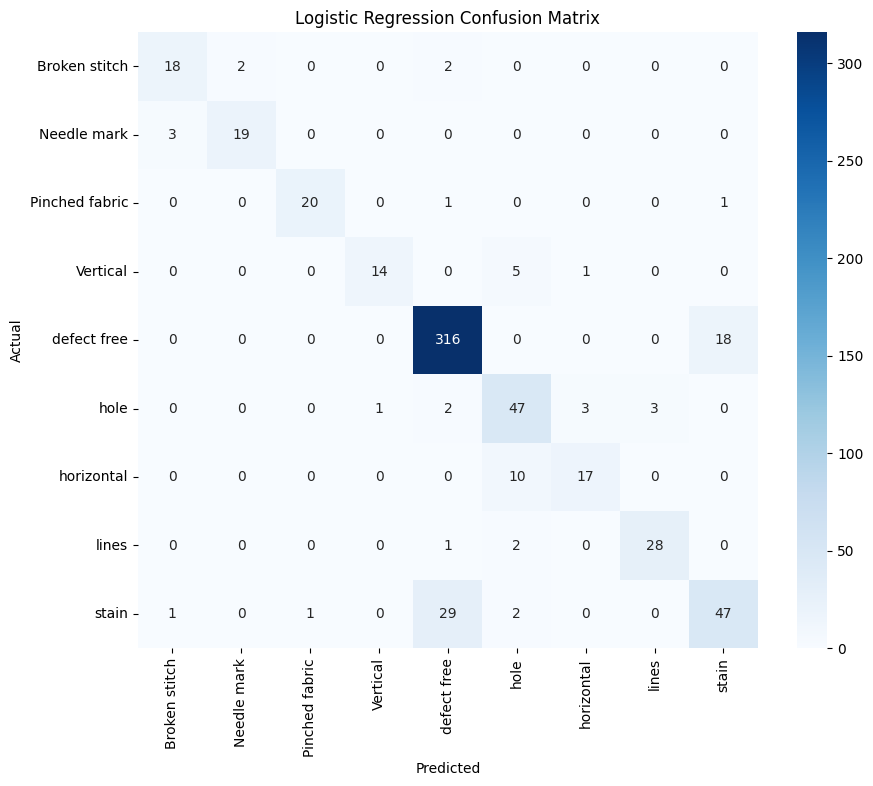

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

PHASE 12 : MLP (Neural Network)
---

TRAIN MLP MODEL
---

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

print("MLP Training Completed")

MLP Training Completed


PREDICTIONS
---

In [ ]:
y_pred_mlp = mlp_model.predict(X_test_scaled)

print("Predictions Generated")

Predictions Generated


ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

mlp_accuracy = accuracy_score(
    y_test,
    y_pred_mlp
)

print(f"MLP Accuracy: {mlp_accuracy*100:.2f}%")

MLP Accuracy: 89.41%


CLASSIFICATION REPORT
---

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=label_encoder.classes_
    )
)

                precision    recall  f1-score   support

 Broken stitch       0.87      0.91      0.89        22
   Needle mark       0.95      0.95      0.95        22
Pinched fabric       0.90      0.86      0.88        22
      Vertical       0.85      0.85      0.85        20
   defect free       0.94      0.96      0.95       334
          hole       0.76      0.86      0.81        56
    horizontal       0.77      0.63      0.69        27
         lines       0.93      0.90      0.92        31
         stain       0.81      0.71      0.76        80

      accuracy                           0.89       614
     macro avg       0.87      0.85      0.86       614
  weighted avg       0.89      0.89      0.89       614



CONFUSION MATRIX
---

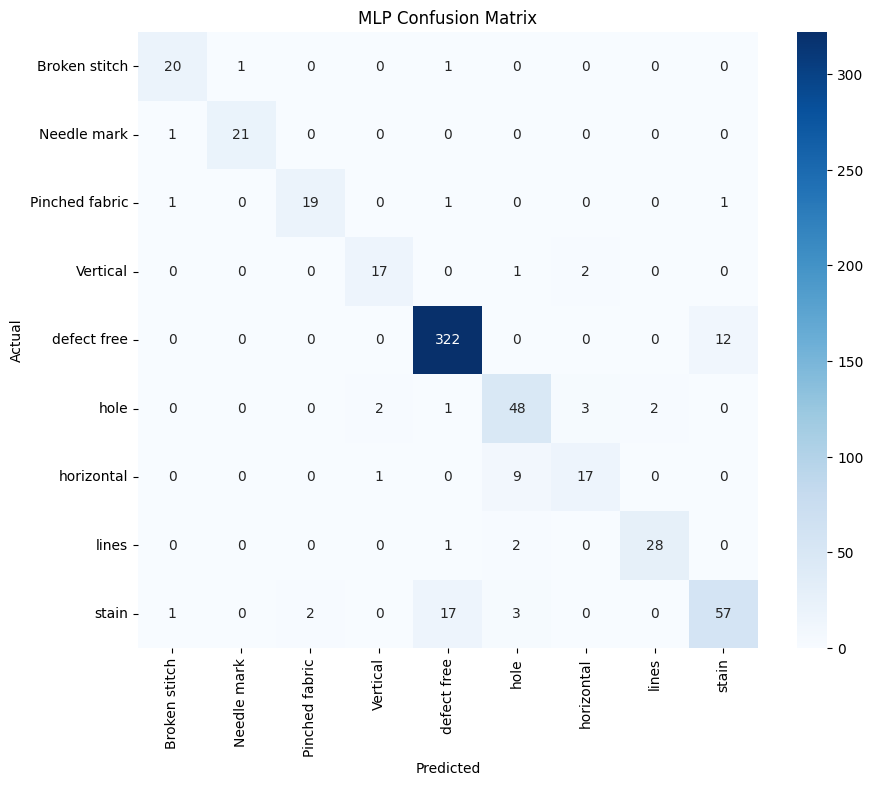

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

PHASE 13 : COLOR HISTOGRAM FEATURES
---

COLOR HISTOGRAM FUNCTION
---

In [ ]:
# =====================================
# PHASE 13 : COLOR HISTOGRAM FUNCTION
# =====================================

import cv2
import numpy as np

def extract_color_histogram(image, bins=(32, 32, 32)):

    hist = cv2.calcHist(
        [image],
        [0, 1, 2],
        None,
        bins,
        [0, 256, 0, 256, 0, 256]
    )

    hist = cv2.normalize(hist, hist)

    return hist.flatten()

TEST FEATURE LENGTH
---

In [ ]:
sample_hist = extract_color_histogram(X_train[0])

print("Color Histogram Length :", len(sample_hist))

Color Histogram Length : 32768


TRAIN FEATURES
---

In [ ]:
# =====================================
# EXTRACT TRAIN COLOR FEATURES
# =====================================

X_train_color = []

for img in X_train:

    features = extract_color_histogram(img)

    X_train_color.append(features)

X_train_color = np.array(X_train_color)

print("Train Color Shape :", X_train_color.shape)

Train Color Shape : (2453, 32768)


TEST FEATURES
---

In [ ]:
# =====================================
# EXTRACT TEST COLOR FEATURES
# =====================================

X_test_color = []

for img in X_test:

    features = extract_color_histogram(img)

    X_test_color.append(features)

X_test_color = np.array(X_test_color)

print("Test Color Shape :", X_test_color.shape)

Test Color Shape : (614, 32768)


SCALE FEATURES
---

In [ ]:
# =====================================
# SCALE COLOR FEATURES
# =====================================

from sklearn.preprocessing import StandardScaler

color_scaler = StandardScaler()

X_train_color_scaled = color_scaler.fit_transform(X_train_color)

X_test_color_scaled = color_scaler.transform(X_test_color)

print(X_train_color_scaled.shape)
print(X_test_color_scaled.shape)

(2453, 32768)
(614, 32768)


QUICK MLP TEST
---

In [ ]:
# =====================================
# MLP ON COLOR HISTOGRAM
# =====================================

from sklearn.neural_network import MLPClassifier

color_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=300,
    random_state=42
)

color_mlp.fit(
    X_train_color_scaled,
    y_train
)

print("Training Completed")

Training Completed


ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

color_pred = color_mlp.predict(
    X_test_color_scaled
)

color_accuracy = accuracy_score(
    y_test,
    color_pred
)

print(
    f"Color Histogram Accuracy: {color_accuracy*100:.2f}%"
)

Color Histogram Accuracy: 84.04%


PHASE 14 : SPATIAL BINNING FEATURES
---

SPATIAL BINNING FUNCTION
---

In [ ]:
# =====================================
# PHASE 14 : SPATIAL BINNING FUNCTION
# =====================================

import cv2
import numpy as np

def extract_spatial_binning(image, size=(32, 32)):

    resized = cv2.resize(image, size)

    return resized.flatten()

TEST FEATURE LENGTH
---

In [ ]:
sample_spatial = extract_spatial_binning(X_train[0])

print("Spatial Feature Length :", len(sample_spatial))

Spatial Feature Length : 3072


TRAIN FEATURES
---

In [ ]:
# =====================================
# TRAIN SPATIAL FEATURES
# =====================================

X_train_spatial = []

for img in X_train:

    features = extract_spatial_binning(img)

    X_train_spatial.append(features)

X_train_spatial = np.array(X_train_spatial)

print("Train Spatial Shape :", X_train_spatial.shape)

Train Spatial Shape : (2453, 3072)


TEST FEATURES
---

In [ ]:
# =====================================
# TEST SPATIAL FEATURES
# =====================================

X_test_spatial = []

for img in X_test:

    features = extract_spatial_binning(img)

    X_test_spatial.append(features)

X_test_spatial = np.array(X_test_spatial)

print("Test Spatial Shape :", X_test_spatial.shape)

Test Spatial Shape : (614, 3072)


SCALE FEATURES
---

In [ ]:
# =====================================
# SCALE SPATIAL FEATURES
# =====================================

from sklearn.preprocessing import StandardScaler

spatial_scaler = StandardScaler()

X_train_spatial_scaled = spatial_scaler.fit_transform(X_train_spatial)

X_test_spatial_scaled = spatial_scaler.transform(X_test_spatial)

print(X_train_spatial_scaled.shape)
print(X_test_spatial_scaled.shape)

(2453, 3072)
(614, 3072)


MLP TRAINING
---

In [ ]:
# =====================================
# MLP ON SPATIAL FEATURES
# =====================================

from sklearn.neural_network import MLPClassifier

spatial_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=300,
    random_state=42
)

spatial_mlp.fit(
    X_train_spatial_scaled,
    y_train
)

print("Training Completed")

Training Completed


ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

spatial_pred = spatial_mlp.predict(
    X_test_spatial_scaled
)

spatial_accuracy = accuracy_score(
    y_test,
    spatial_pred
)

print(
    f"Spatial Binning Accuracy: {spatial_accuracy*100:.2f}%"
)

Spatial Binning Accuracy: 86.48%


PHASE 15 : FEATURE FUSION
---

COMBINE TRAIN FEATURES
---

In [ ]:
# =====================================
# PHASE 15 : FEATURE FUSION
# =====================================

X_train_combined = np.hstack([
    X_train_hog,
    X_train_color,
    X_train_spatial
])

print("Combined Train Shape :", X_train_combined.shape)

Combined Train Shape : (2453, 62084)


COMBINE TEST FEATURES
---

In [ ]:
X_test_combined = np.hstack([
    X_test_hog,
    X_test_color,
    X_test_spatial
])

print("Combined Test Shape :", X_test_combined.shape)

Combined Test Shape : (614, 62084)


SCALE COMBINED FEATURES
---

In [ ]:
from sklearn.preprocessing import StandardScaler

combined_scaler = StandardScaler()

X_train_combined_scaled = combined_scaler.fit_transform(
    X_train_combined
)

X_test_combined_scaled = combined_scaler.transform(
    X_test_combined
)

print(X_train_combined_scaled.shape)
print(X_test_combined_scaled.shape)

(2453, 62084)
(614, 62084)


MLP ON COMBINED FEATURES
---

In [ ]:
from sklearn.neural_network import MLPClassifier

combined_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=300,
    random_state=42
)

combined_mlp.fit(
    X_train_combined_scaled,
    y_train
)

print("Combined Feature Training Completed")

Combined Feature Training Completed


FINAL ACCURACY
---

In [ ]:
from sklearn.metrics import accuracy_score

combined_pred = combined_mlp.predict(
    X_test_combined_scaled
)

combined_accuracy = accuracy_score(
    y_test,
    combined_pred
)

print(
    f"Combined Features Accuracy: {combined_accuracy*100:.2f}%"
)

Combined Features Accuracy: 90.88%


=====================================
PHASE 16 : CNN BASED CLASSIFICATION
=====================================

IMPORTS
---

In [ ]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


LOAD DATASET
---

In [ ]:
dataset_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Processed_Dataset"

images = []
labels = []

classes = sorted(os.listdir(dataset_path))

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # CNN ke liye smaller size
        img = cv2.resize(img, (128,128))

        images.append(img)
        labels.append(cls)

print("Images Loaded :", len(images))

Images Loaded : 3067


LABEL ENCODING
---

In [ ]:
images = np.array(images)

label_encoder = LabelEncoder()

labels_encoded = label_encoder.fit_transform(labels)

print(images.shape)
print(labels_encoded.shape)

(3067, 128, 128, 3)
(3067,)


NORMALIZATION
---

In [ ]:
images = images.astype("float32") / 255.0

TRAIN TEST SPLIT
---

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.20,
    random_state=42,
    stratify=labels_encoded
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (2453, 128, 128, 3)
Test Shape  : (614, 128, 128, 3)


CNN MODEL
---

In [ ]:
cnn_model = Sequential([

    Input(shape=(128,128,3)),

    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(9, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,329 (110.66 KB)

 Trainable params: 28,329 (110.66 KB)

 Non-trainable params: 0 (0.00 B)

COMPILE MODEL
---

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAIN CNN
---

In [ ]:
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=16,
    verbose=1
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 42s 272ms/step - accuracy: 0.7684 - loss: 0.5467 - val_accuracy: 0.7932 - val_loss: 0.5016
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 37s 240ms/step - accuracy: 0.7774 - loss: 0.5359 - val_accuracy: 0.7769 - val_loss: 0.5066
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.7680 - loss: 0.5669 - val_accuracy: 0.7850 - val_loss: 0.5155
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 37s 241ms/step - accuracy: 0.7860 - loss: 0.5006 - val_accuracy: 0.8127 - val_loss: 0.4684
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 39s 255ms/step - accuracy: 0.7876 - loss: 0.4971 - val_accuracy: 0.7964 - val_loss: 0.4656
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 37s 241ms/step - accuracy: 0.7925 - loss: 0.4788 - val_accuracy: 0.7427 - val_loss: 0.6002
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 40s 262ms/step - accuracy: 0.7994 - loss: 0.4843 - val_accuracy: 0.8111 - val_loss: 0.4442
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 245ms/step - accuracy: 0.7778 - loss: 0

EVALUATE CNN
---

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"CNN Accuracy: {cnn_accuracy*100:.2f}%")

CNN Accuracy: 79.48%


FINAL COMPARISON
---

In [ ]:
print("========== FINAL COMPARISON ==========")

print("Naive Bayes                : 56.84%")
print("SVM                        : 85.34%")
print("Logistic Regression        : 85.83%")
print("MLP (HOG)                  : 88.27%")
print("MLP (Combined Features)    : 90.55%")
print(f"CNN                        : {cnn_accuracy*100:.2f}%")

========== FINAL COMPARISON ==========
Naive Bayes                : 56.84%
SVM                        : 85.34%
Logistic Regression        : 85.83%
MLP (HOG)                  : 88.27%
MLP (Combined Features)    : 90.55%
CNN                        : 79.48%


PREDICTION FUNCTION
---

In [ ]:
# ==========================================================
# FABRIC DEFECT PREDICTION FUNCTION
# ==========================================================

import cv2
import numpy as np
from skimage.feature import hog

def predict_fabric_defect(image_path):

    # Read Image
    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(image, (224,224))


    # -----------------------------
    # HOG FEATURES
    # -----------------------------
    hog_features = hog(
        cv2.cvtColor(image, cv2.COLOR_RGB2GRAY),
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )


    # -----------------------------
    # COLOR HISTOGRAM
    # -----------------------------
    color_hist = cv2.calcHist(
        [image],
        [0,1,2],
        None,
        (32,32,32),
        [0,256,0,256,0,256]
    )

    color_hist = cv2.normalize(
        color_hist,
        color_hist
    ).flatten()


    # -----------------------------
    # SPATIAL BINNING
    # -----------------------------
    spatial = cv2.resize(
        image,
        (32,32)
    ).flatten()


    # -----------------------------
    # COMBINE FEATURES
    # -----------------------------
    features = np.hstack([
        hog_features,
        color_hist,
        spatial
    ])


    # reshape
    features = features.reshape(1,-1)

    # scale
    features = combined_scaler.transform(features)

    # predict
    prediction = combined_mlp.predict(features)

    class_name = label_encoder.inverse_transform(
        prediction
    )[0]

    print("Predicted Class :", class_name)

    if class_name == "defect free":
        print("Fabric Status : Fabric is OK")
    else:
        print("Fabric Status : Defect Detected")

In [ ]:
sample_image = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Fabric_Test_Images/test.jpeg"

predict_fabric_defect(sample_image)

Predicted Class : hole
Fabric Status : Defect Detected


SAVE MLP Combined TRAINED MODEL
---

In [ ]:
import joblib

joblib.dump(
    combined_mlp,
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/fabric_defect_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


SAVE SCALER
---

In [ ]:
import joblib

joblib.dump(
    combined_scaler,
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/fabric_scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


SAVE LABEL ENCODER
---

In [ ]:
import joblib

joblib.dump(
    label_encoder,
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/label_encoder.pkl"
)

print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully


VERIFY SAVED FILES
---

In [ ]:
import os

project_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project"

print(os.listdir(project_path))

['Dataset', 'Processed_Dataset', 'Fabric_Test_Images', 'fabric_defect_model.pkl', 'fabric_scaler.pkl', 'label_encoder.pkl']


TEST LOADING
---

In [ ]:
import joblib

loaded_model = joblib.load(
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/fabric_defect_model.pkl"
)

loaded_scaler = joblib.load(
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/fabric_scaler.pkl"
)

loaded_encoder = joblib.load(
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/label_encoder.pkl"
)

print("All Files Loaded Successfully")

All Files Loaded Successfully


PHASE 17 — Prediction Using Saved Model
---

LOAD SAVED FILES
---

In [ ]:
# ==========================================================
# LOAD SAVED MODEL FILES
# ==========================================================

import joblib

model = joblib.load(
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/fabric_defect_model.pkl"
)

scaler = joblib.load(
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/fabric_scaler.pkl"
)

encoder = joblib.load(
    "/content/drive/MyDrive/ML_Fabric_Defect_Project/label_encoder.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


IMPORTS
---

In [ ]:
# ==========================================================
# REQUIRED LIBRARIES
# ==========================================================

import cv2
import numpy as np

from skimage.feature import hog

PREDICTION FUNCTION
---

In [ ]:
# ==========================================================
# FABRIC DEFECT PREDICTION
# ==========================================================

def predict_fabric_defect(image_path):

    image = cv2.imread(image_path)

    if image is None:

        return None, None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (224,224)
    )

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    color_hist = cv2.calcHist(
        [image],
        [0,1,2],
        None,
        (32,32,32),
        [0,256,0,256,0,256]
    )

    color_hist = cv2.normalize(
        color_hist,
        color_hist
    ).flatten()

    spatial = cv2.resize(
        image,
        (32,32)
    ).flatten()

    features = np.hstack([
        hog_features,
        color_hist,
        spatial
    ])

    features = features.reshape(1,-1)

    features = scaler.transform(features)

    prediction = model.predict(features)

    class_name = encoder.inverse_transform(
        prediction
    )[0]

    if class_name == "defect free":

        status = "Fabric is OK"

    else:

        status = "Defect Detected"

    return class_name, status

TEST IMAGE
---

In [ ]:
image_path = "/content/drive/MyDrive/ML_Fabric_Defect_Project/Fabric_Test_Images/test.jpeg"

predicted_class, fabric_status = predict_fabric_defect(image_path)

print("Predicted Class :", predicted_class)

print("Fabric Status :", fabric_status)

Predicted Class : hole
Fabric Status : Defect Detected
